(650000,)


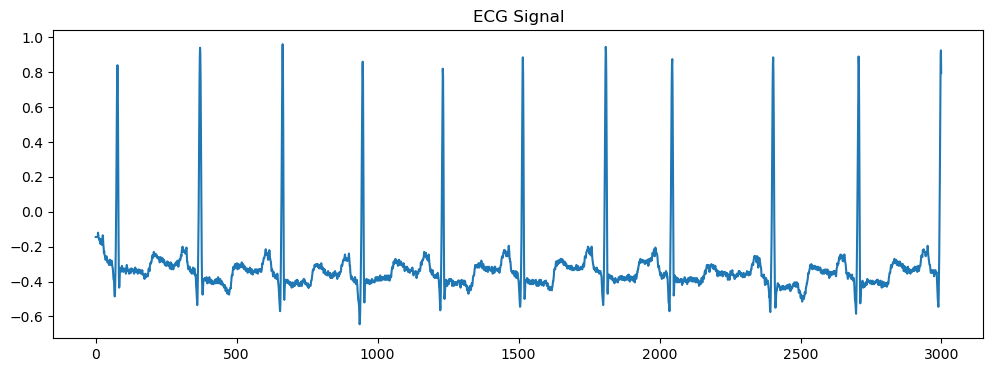

In [1]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord("100", pn_dir="mitdb")
signal = record.p_signal[:, 0]
print(signal.shape)

plt.figure(figsize=(12, 4))
plt.plot(signal[:3000])
plt.title("ECG Signal")
plt.show()

In [4]:
wfdb.dl_database('mitdb', dl_dir='data/mit-bih-arrhythmia-database-1.0.0', records=['100'])

Generating record list for: 100
Generating list of all files for: 100
Created local base download directory: data/mit-bih-arrhythmia-database-1.0.0
Finished downloading files


In [5]:
annotation = wfdb.rdann(
    "data/mit-bih-arrhythmia-database-1.0.0/100",
    "atr"
)

print(annotation.symbol[:30])

['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [6]:
from collections import Counter

label_count = Counter(
    annotation.symbol
)

print(label_count)

Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})


In [7]:
label_map = {
'N':'Normal',
'V':'Ventricular',
'A':'Atrial',
'F':'Fusion',
'L':'Left bundle',
'R':'Right bundle'
}

for i in label_map:
    print(i,"→",label_map[i])

N → Normal
V → Ventricular
A → Atrial
F → Fusion
L → Left bundle
R → Right bundle


In [8]:
binary_labels=[]

for s in annotation.symbol:

    if s=="N":
        binary_labels.append(0)

    else:
        binary_labels.append(1)

print(
binary_labels[:30]
)

[1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [9]:
from collections import Counter

print(
Counter(
binary_labels
)
)

Counter({0: 2239, 1: 35})


In [10]:
window_size = 512

segments = []

for i in range(
    0,
    len(signal)-window_size,
    window_size
):

    segment = signal[
        i:i+window_size
    ]

    segments.append(
        segment
    )

print(
len(segments)
)

print(
segments[0].shape
)

1269
(512,)


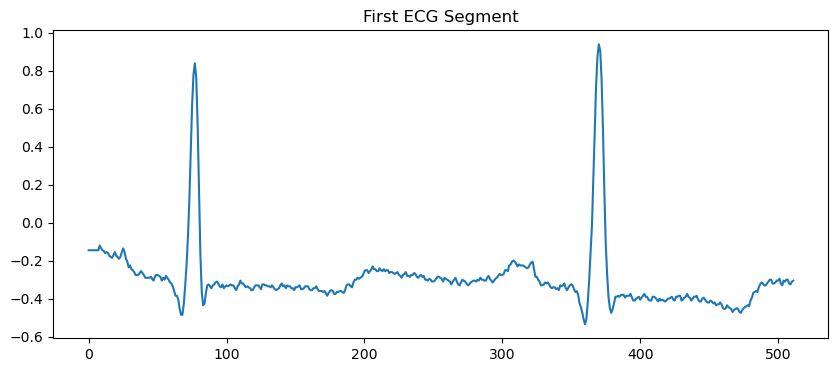

In [11]:
plt.figure(
figsize=(10,4)
)

plt.plot(
segments[0]
)

plt.title(
"First ECG Segment"
)

plt.show()

In [12]:
import numpy as np

segments = np.array(
    segments
)

print(
segments.shape
)

(1269, 512)


In [13]:
segments = (
segments
-
segments.mean()
) / (
segments.std()
)

print(
segments.mean()
)

print(
segments.std()
)

-2.4310734670426743e-16
0.9999999999999997


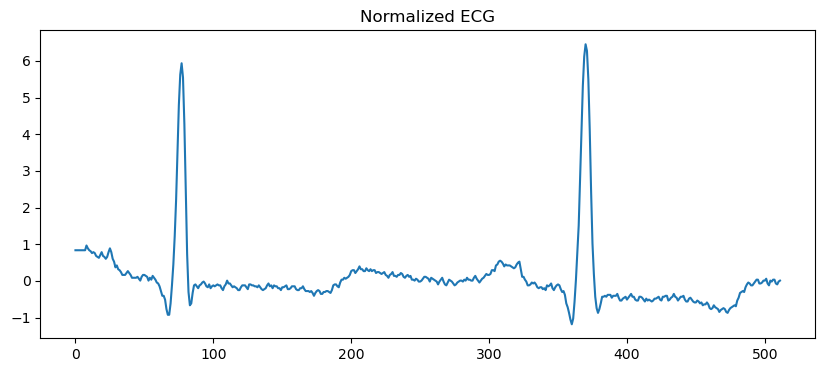

In [14]:
plt.figure(
figsize=(10,4)
)

plt.plot(
segments[0]
)

plt.title(
"Normalized ECG"
)

plt.show()

In [15]:
segments = np.array(
    segments,
    dtype=np.float32
)

segments = (
    segments
    -
    np.mean(segments)
) / np.std(segments)

print(
"Shape:",
segments.shape
)

print(
"Mean:",
np.mean(segments)
)

print(
"Std:",
np.std(segments)
)

Shape: (1269, 512)
Mean: -6.329177e-09
Std: 1.0000001


In [16]:
import torch
from torch.utils.data import Dataset


class ECGDataset(Dataset):

    def __init__(self, X):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx]


dataset = ECGDataset(
    segments
)

print(
"Dataset size:",
len(dataset)
)

print(
"One sample shape:",
dataset[0].shape
)

Dataset size: 1269
One sample shape: torch.Size([512])


In [17]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print(
"Number of batches:",
len(loader)
)

Number of batches: 40


In [18]:
for batch in loader:

    print(
        batch.shape
    )

    break

torch.Size([32, 512])


In [19]:
for batch in loader:

    batch = batch.unsqueeze(1)

    print(
        batch.shape
    )

    break

torch.Size([32, 1, 512])


In [20]:
import torch.nn as nn


class BaselineModel(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                512,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                2
            )

        )

    def forward(
        self,
        x
    ):

        return self.model(
            x
        )


model = BaselineModel()

print(model)

BaselineModel(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [21]:
for batch in loader:

    batch = batch.unsqueeze(1)

    output = model(
        batch
    )

    print(
        output.shape
    )

    break

torch.Size([32, 2])


In [22]:
num_segments = len(
    segments
)

labels = np.zeros(
    num_segments,
    dtype=np.int64
)

print(
labels.shape
)

print(
labels[:10]
)

(1269,)
[0 0 0 0 0 0 0 0 0 0]


In [23]:
class ECGDataset(
Dataset
):

    def __init__(
        self,
        X,
        y
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(
        self
    ):

        return len(
            self.X
        )

    def __getitem__(
        self,
        idx
    ):

        return (
            self.X[idx],
            self.y[idx]
        )


dataset = ECGDataset(
segments,
labels
)

loader = DataLoader(
dataset,
batch_size=32,
shuffle=True
)

print(
len(dataset)
)

1269


In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
model.parameters(),
lr=0.001
)

epochs = 3

for epoch in range(
epochs
):

    total_loss = 0

    for X,y in loader:

        X = X.unsqueeze(1)

        pred = model(
            X
        )

        loss = criterion(
            pred,
            y
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
        )

    print(
        "Epoch",
        epoch+1,
        "Loss:",
        total_loss
    )

Epoch 1 Loss: 6.257198311388493
Epoch 2 Loss: 0.25630755815654993
Epoch 3 Loss: 0.11576421034988016


In [25]:
segment_labels = []

ratio = len(
binary_labels
) / len(
segments
)

for i in range(
len(segments)
):

    idx = int(
        i * ratio
    )

    segment_labels.append(
        binary_labels[idx]
    )

segment_labels = np.array(
segment_labels
)

print(
segment_labels.shape
)

print(
segment_labels[:20]
)

(1269,)
[1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [26]:
from collections import Counter

print(
Counter(
segment_labels
)
)

Counter({np.int64(0): 1250, np.int64(1): 19})


In [27]:
dataset = ECGDataset(
segments,
segment_labels
)

loader = DataLoader(
dataset,
batch_size=32,
shuffle=True
)

print(
len(dataset)
)

1269


In [29]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
model.parameters(),
lr=0.001
)

epochs = 5

for epoch in range(
epochs
):

    total_loss = 0

    correct = 0

    total = 0

    for X,y in loader:

        X = X.unsqueeze(1)

        pred = model(X)

        loss = criterion(
            pred,
            y
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predicted = pred.argmax(
            dim=1
        )

        correct += (
            predicted==y
        ).sum().item()

        total += len(y)

    print(
        "Epoch:",
        epoch+1
    )

    print(
        "Loss:",
        total_loss
    )

    print(
        "Accuracy:",
        correct/total
    )

Epoch: 1
Loss: 1.3801098838448524
Accuracy: 0.9858156028368794
Epoch: 2
Loss: 1.1578131709247828
Accuracy: 0.9889676910953507
Epoch: 3
Loss: 1.003650217782706
Accuracy: 0.9897557131599685
Epoch: 4
Loss: 0.6766292089014314
Accuracy: 0.9944838455476753
Epoch: 5
Loss: 0.5594302060781047
Accuracy: 0.996059889676911


In [30]:
all_pred=[]

all_true=[]

model.eval()

with torch.no_grad():

    for X,y in loader:

        X = X.unsqueeze(1)

        pred = model(X)

        pred = pred.argmax(
            dim=1
        )

        all_pred.extend(
            pred.numpy()
        )

        all_true.extend(
            y.numpy()
        )

print(
len(all_pred)
)

1269


In [31]:
from sklearn.metrics import (
classification_report
)

print(
classification_report(
all_true,
all_pred
)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1250
           1       1.00      0.95      0.97        19

    accuracy                           1.00      1269
   macro avg       1.00      0.97      0.99      1269
weighted avg       1.00      1.00      1.00      1269



In [32]:
from sklearn.model_selection import (
train_test_split
)

X_train,\
X_test,\
y_train,\
y_test = train_test_split(

segments,
segment_labels,

test_size=0.2,

random_state=42,

stratify=segment_labels
)

print(
X_train.shape
)

print(
X_test.shape
)

(1015, 512)
(254, 512)


In [33]:
train_dataset = ECGDataset(
X_train,
y_train
)

test_dataset = ECGDataset(
X_test,
y_test
)

train_loader = DataLoader(
train_dataset,
batch_size=32,
shuffle=True
)

test_loader = DataLoader(
test_dataset,
batch_size=32,
shuffle=False
)

print(
len(train_dataset)
)

print(
len(test_dataset)
)

1015
254


In [34]:
import torch.nn as nn


class BaselineModel(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                512,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                2
            )

        )

    def forward(
        self,
        x
    ):

        return self.model(
            x
        )


model = BaselineModel()

In [35]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 5

for epoch in range(
    epochs
):

    model.train()

    total_loss = 0

    correct = 0

    total = 0

    for X,y in train_loader:

        X = X.unsqueeze(1)

        pred = model(X)

        loss = criterion(
            pred,
            y
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
        )

        predicted = pred.argmax(
            dim=1
        )

        correct += (
            predicted==y
        ).sum().item()

        total += len(y)

    print(
        "Epoch",
        epoch+1
    )

    print(
        "Loss",
        total_loss
    )

    print(
        "Train Accuracy",
        correct/total
    )

Epoch 1
Loss 7.279183346778154
Train Accuracy 0.9596059113300492
Epoch 2
Loss 1.986935107037425
Train Accuracy 0.9852216748768473
Epoch 3
Loss 1.4944116370752454
Train Accuracy 0.9852216748768473
Epoch 4
Loss 1.2044053627178073
Train Accuracy 0.9852216748768473
Epoch 5
Loss 1.0158671224489808
Train Accuracy 0.9852216748768473


In [36]:
from sklearn.metrics import (
classification_report
)

model.eval()

all_pred=[]

all_true=[]

with torch.no_grad():

    for X,y in test_loader:

        X = X.unsqueeze(1)

        pred = model(
            X
        )

        pred = pred.argmax(
            dim=1
        )

        all_pred.extend(
            pred.numpy()
        )

        all_true.extend(
            y.numpy()
        )

print(
classification_report(
all_true,
all_pred
)
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       250
           1       0.00      0.00      0.00         4

    accuracy                           0.98       254
   macro avg       0.49      0.50      0.50       254
weighted avg       0.97      0.98      0.98       254



c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
weights = torch.tensor(
[
1.0,
20.0
],
dtype=torch.float32
)

criterion = nn.CrossEntropyLoss(
weight=weights
)

In [38]:
def train_model(
    model,
    loader,
    criterion,
    optimizer,
    epochs=5
):

    for epoch in range(
        epochs
    ):

        model.train()

        total_loss = 0

        correct = 0

        total = 0

        for X,y in loader:

            X = X.unsqueeze(1)

            pred = model(
                X
            )

            loss = criterion(
                pred,
                y
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
            )

            predicted = pred.argmax(
                dim=1
            )

            correct += (
                predicted==y
            ).sum().item()

            total += len(y)

        print(
            f"Epoch {epoch+1}"
        )

        print(
            "Loss:",
            total_loss
        )

        print(
            "Accuracy:",
            correct/total
        )

In [39]:
from sklearn.metrics import (
classification_report
)


def evaluate(
    model,
    loader
):

    model.eval()

    pred_all=[]

    true_all=[]

    with torch.no_grad():

        for X,y in loader:

            X = X.unsqueeze(
                1
            )

            pred = model(
                X
            )

            pred = pred.argmax(
                dim=1
            )

            pred_all.extend(
                pred.numpy()
            )

            true_all.extend(
                y.numpy()
            )

    print(

classification_report(
true_all,
pred_all
)

)

In [40]:
model = BaselineModel()

weights = torch.tensor(
[
1.0,
20.0
]
)

criterion = nn.CrossEntropyLoss(
weight=weights
)

optimizer = torch.optim.Adam(
model.parameters(),
lr=0.001
)

train_model(
model,
train_loader,
criterion,
optimizer,
epochs=5
)

Epoch 1
Loss: 17.35252968966961
Accuracy: 0.8532019704433498
Epoch 2
Loss: 9.181015647947788
Accuracy: 0.9714285714285714
Epoch 3
Loss: 6.004302013665438
Accuracy: 0.9733990147783251
Epoch 4
Loss: 4.552099637687206
Accuracy: 0.9773399014778326
Epoch 5
Loss: 3.6797252781689167
Accuracy: 0.9852216748768473


In [41]:
evaluate(
model,
test_loader
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       250
           1       0.00      0.00      0.00         4

    accuracy                           0.97       254
   macro avg       0.49      0.49      0.49       254
weighted avg       0.97      0.97      0.97       254



In [2]:
import wfdb
import numpy as np

record = wfdb.rdrecord(
    "data/mit-bih-arrhythmia-database-1.0.0/100"
)

signal = record.p_signal[:,0]

annotation = wfdb.rdann(
    "data/mit-bih-arrhythmia-database-1.0.0/100",
    "atr"
)

print(
signal.shape
)

print(
len(annotation.symbol)
)

(650000,)
2274


In [3]:
window_size = 512

segments = []

segment_labels = []

ratio = len(signal) / len(annotation.sample)

for i in range(
0,
len(signal)-window_size,
window_size
):

    segment = signal[
        i:i+window_size
    ]

    segments.append(
        segment
    )

    start = i

    end = i+window_size

    label = 0

    for beat,label_symbol in zip(
        annotation.sample,
        annotation.symbol
    ):

        if (
            beat >= start
            and
            beat < end
        ):

            if (
                label_symbol
                != "N"
            ):

                label = 1

                break

    segment_labels.append(
        label
    )

segments = np.array(
segments,
dtype=np.float32
)

segment_labels = np.array(
segment_labels
)

print(
segments.shape
)

print(
segment_labels.shape
)

(1269, 512)
(1269,)


In [4]:
from collections import Counter

print(
Counter(
segment_labels
)
)

Counter({np.int64(0): 1234, np.int64(1): 35})


In [9]:
from sklearn.model_selection import train_test_split

print("Import successful")

X_train, X_test, y_train, y_test = train_test_split(
    segments,
    segment_labels,
    test_size=0.2,
    random_state=42,
    stratify=segment_labels
)

print("Split completed")

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Import successful
Split completed
Train: (1015, 512)
Test: (254, 512)


In [11]:
import torch
from torch.utils.data import Dataset


class ECGDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(
            self.X
        )

    def __getitem__(
        self,
        idx
    ):

        return (
            self.X[idx],
            self.y[idx]
        )


print("Dataset Class Ready")

Dataset Class Ready


In [12]:
train_dataset = ECGDataset(
    X_train,
    y_train
)

test_dataset = ECGDataset(
    X_test,
    y_test
)

print(
"Train size:",
len(train_dataset)
)

print(
"Test size:",
len(test_dataset)
)

Train size: 1015
Test size: 254


In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(
"Train batches:",
len(train_loader)
)

print(
"Test batches:",
len(test_loader)
)

Train batches: 32
Test batches: 8


In [16]:
import torch
import torch.nn as nn


class BaselineModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                512,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                2
            )
        )

    def forward(
        self,
        x
    ):

        return self.network(x)


model = BaselineModel()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

print("Model created successfully")

BaselineModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)
Model created successfully


In [18]:
from sklearn.metrics import classification_report
import torch


def train_model(
    model,
    loader,
    criterion,
    optimizer,
    epochs=5
):

    for epoch in range(epochs):

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for X, y in loader:

            X = X.unsqueeze(1)

            pred = model(X)

            loss = criterion(
                pred,
                y
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            predicted = pred.argmax(
                dim=1
            )

            correct += (
                predicted == y
            ).sum().item()

            total += len(y)

        print(
            f"Epoch {epoch+1}"
        )

        print(
            "Loss:",
            round(
                total_loss,
                4
            )
        )

        print(
            "Accuracy:",
            round(
                correct/total,
                4
            )
        )


def evaluate(
    model,
    loader
):

    model.eval()

    pred_all = []

    true_all = []

    with torch.no_grad():

        for X, y in loader:

            X = X.unsqueeze(1)

            pred = model(X)

            pred = pred.argmax(
                dim=1
            )

            pred_all.extend(
                pred.numpy()
            )

            true_all.extend(
                y.numpy()
            )

    print(
        classification_report(
            true_all,
            pred_all
        )
    )


print("Functions Ready")

Functions Ready


In [19]:
train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    epochs=5
)

Epoch 1
Loss: 6.2342
Accuracy: 0.9586
Epoch 2
Loss: 4.1593
Accuracy: 0.9724
Epoch 3
Loss: 4.112
Accuracy: 0.9724
Epoch 4
Loss: 3.9982
Accuracy: 0.9724
Epoch 5
Loss: 3.8727
Accuracy: 0.9724


In [20]:
evaluate(
    model,
    test_loader
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       247
           1       0.00      0.00      0.00         7

    accuracy                           0.97       254
   macro avg       0.49      0.50      0.49       254
weighted avg       0.95      0.97      0.96       254



c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
import torch
import torch.nn as nn


class ECGTransformer(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.input_proj = nn.Linear(
            1,
            64
        )

        encoder = nn.TransformerEncoderLayer(

            d_model=64,

            nhead=4,

            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(

            encoder,

            num_layers=2
        )

        self.fc = nn.Linear(
            64,
            2
        )

    def forward(
        self,
        x
    ):

        x = x.transpose(
            1,
            2
        )

        x = self.input_proj(
            x
        )

        x = self.transformer(
            x
        )

        x = x.mean(
            dim=1
        )

        return self.fc(
            x
        )


model = ECGTransformer()

print("Transformer Ready")

Transformer Ready


In [22]:
weights = torch.tensor(
[
1.0,
35.0
]
)

criterion = nn.CrossEntropyLoss(
weight=weights
)

optimizer = torch.optim.Adam(

model.parameters(),

lr=0.0005
)

In [23]:
train_model(

model,

train_loader,

criterion,

optimizer,

epochs=10
)

Epoch 1
Loss: 26.4854
Accuracy: 0.73
Epoch 2
Loss: 22.218
Accuracy: 0.8926
Epoch 3
Loss: 20.3423
Accuracy: 0.9724
Epoch 4
Loss: 22.8775
Accuracy: 0.7448
Epoch 5
Loss: 21.4113
Accuracy: 0.8857
Epoch 6
Loss: 22.2504
Accuracy: 0.9399
Epoch 7
Loss: 21.5561
Accuracy: 0.9724
Epoch 8
Loss: 21.3744
Accuracy: 0.9724
Epoch 9
Loss: 21.3534
Accuracy: 0.9724
Epoch 10
Loss: 22.4312
Accuracy: 0.9724


In [24]:
evaluate(

model,

test_loader
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       247
           1       0.00      0.00      0.00         7

    accuracy                           0.97       254
   macro avg       0.49      0.50      0.49       254
weighted avg       0.95      0.97      0.96       254



c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np

X_flat = segments

y = segment_labels

ros = RandomOverSampler(
    random_state=42
)

X_resampled, y_resampled = ros.fit_resample(
    X_flat,
    y
)

print(
X_resampled.shape
)

print(
np.bincount(
y_resampled
)
)

(2468, 512)
[1234 1234]


In [26]:
X_train,\
X_test,\
y_train,\
y_test = train_test_split(

X_resampled,

y_resampled,

test_size=0.2,

random_state=42,

stratify=y_resampled
)

print(
X_train.shape
)

print(
X_test.shape
)

(1974, 512)
(494, 512)


In [1]:
import torch
import torch.nn as nn


class ECGTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.input_proj = nn.Linear(
            1,
            64
        )

        encoder = nn.TransformerEncoderLayer(

            d_model=64,

            nhead=4,

            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(

            encoder,

            num_layers=2
        )

        self.fc = nn.Linear(
            64,
            2
        )

    def forward(
        self,
        x
    ):

        # (batch,1,512)
        x = x.transpose(
            1,
            2
        )

        # (batch,512,64)
        x = self.input_proj(
            x
        )

        x = self.transformer(
            x
        )

        # global average pooling
        x = x.mean(
            dim=1
        )

        return self.fc(
            x
        )


print("Transformer Ready")

Transformer Ready


In [3]:
from sklearn.metrics import classification_report
import torch


def train_model(
    model,
    loader,
    criterion,
    optimizer,
    epochs=10
):

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        correct = 0

        total = 0

        for X,y in loader:

            X = X.unsqueeze(1)

            pred = model(X)

            loss = criterion(
                pred,
                y
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            predicted = pred.argmax(
                dim=1
            )

            correct += (
                predicted==y
            ).sum().item()

            total += len(y)

        print(
            f"Epoch {epoch+1}"
        )

        print(
            "Loss:",
            round(
                total_loss,
                4
            )
        )

        print(
            "Accuracy:",
            round(
                correct/total,
                4
            )
        )



def evaluate(
    model,
    loader
):

    model.eval()

    pred_all=[]

    true_all=[]

    with torch.no_grad():

        for X,y in loader:

            X = X.unsqueeze(1)

            pred = model(X)

            pred = pred.argmax(
                dim=1
            )

            pred_all.extend(
                pred.cpu().numpy()
            )

            true_all.extend(
                y.cpu().numpy())

    print(
        classification_report(
            true_all,
            pred_all
        )
    )


print("Training Functions Ready")

Training Functions Ready


In [11]:
import wfdb
import numpy as np

record = wfdb.rdrecord(
    "data/mit-bih-arrhythmia-database-1.0.0/100"
)

signal = record.p_signal[:,0]

annotation = wfdb.rdann(
    "data/mit-bih-arrhythmia-database-1.0.0/100",
    "atr"
)

print(signal.shape)
print(len(annotation.symbol))

(650000,)
2274


In [12]:
window_size = 512

segments=[]

segment_labels=[]

for i in range(
    0,
    len(signal)-window_size,
    window_size
):

    segments.append(
        signal[
            i:i+window_size
        ]
    )

    label = 0

    for beat,symbol in zip(
        annotation.sample,
        annotation.symbol
    ):

        if (
            beat>=i
            and
            beat<i+window_size
        ):

            if symbol!="N":

                label=1

                break

    segment_labels.append(
        label
    )

segments=np.array(
    segments,
    dtype=np.float32
)

segment_labels=np.array(
    segment_labels
)

print(segments.shape)
print(segment_labels.shape)

(1269, 512)
(1269,)


In [13]:
from collections import Counter

print(
Counter(
segment_labels
)
)

Counter({np.int64(0): 1234, np.int64(1): 35})


In [14]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    random_state=42
)

X_resampled, y_resampled = ros.fit_resample(
    segments,
    segment_labels
)

print(X_resampled.shape)

import numpy as np

print(
np.bincount(
y_resampled
)
)

(2468, 512)
[1234 1234]


In [15]:
from sklearn.model_selection import train_test_split

X_train,\
X_test,\
y_train,\
y_test = train_test_split(

X_resampled,

y_resampled,

test_size=0.2,

random_state=42,

stratify=y_resampled
)

print(X_train.shape)

print(X_test.shape)

(1974, 512)
(494, 512)


In [17]:
import torch
from torch.utils.data import Dataset


class ECGDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(
            self.X
        )

    def __getitem__(
        self,
        idx
    ):

        return (
            self.X[idx],
            self.y[idx]
        )


print("ECGDataset Ready")

ECGDataset Ready


In [18]:
from torch.utils.data import DataLoader

train_dataset = ECGDataset(
X_train,
y_train
)

test_dataset = ECGDataset(
X_test,
y_test
)

train_loader = DataLoader(
train_dataset,
batch_size=32,
shuffle=True
)

test_loader = DataLoader(
test_dataset,
batch_size=32,
shuffle=False
)

print(
len(train_loader)
)

print(
len(test_loader)
)

62
16


In [19]:
from torch.utils.data import DataLoader

train_dataset = ECGDataset(
X_train,
y_train
)

test_dataset = ECGDataset(
X_test,
y_test
)

train_loader = DataLoader(
train_dataset,
batch_size=32,
shuffle=True
)

test_loader = DataLoader(
test_dataset,
batch_size=32,
shuffle=False
)

print(
"Train batches:",
len(train_loader)
)

print(
"Test batches:",
len(test_loader)
)

Train batches: 62
Test batches: 16


In [20]:
import torch
import torch.nn as nn


class ECGTransformer(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.input_proj = nn.Linear(
            1,
            64
        )

        encoder = nn.TransformerEncoderLayer(

            d_model=64,

            nhead=4,

            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(

            encoder,

            num_layers=2
        )

        self.fc = nn.Linear(
            64,
            2
        )

    def forward(
        self,
        x
    ):

        x = x.transpose(
            1,
            2
        )

        x = self.input_proj(
            x
        )

        x = self.transformer(
            x
        )

        x = x.mean(
            dim=1
        )

        return self.fc(
            x
        )


print("Transformer Ready")

Transformer Ready


In [21]:
from sklearn.metrics import classification_report


def train_model(
    model,
    loader,
    criterion,
    optimizer,
    epochs=10
):

    for epoch in range(epochs):

        model.train()

        total_loss=0
        correct=0
        total=0

        for X,y in loader:

            X=X.unsqueeze(1)

            pred=model(X)

            loss=criterion(
                pred,
                y
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss+=loss.item()

            predicted=pred.argmax(
                dim=1
            )

            correct+=(
                predicted==y
            ).sum().item()

            total+=len(y)

        print(
            epoch+1,
            round(
                correct/total,
                3
            )
        )


def evaluate(
    model,
    loader
):

    model.eval()

    preds=[]

    trues=[]

    with torch.no_grad():

        for X,y in loader:

            X=X.unsqueeze(1)

            pred=model(X)

            pred=pred.argmax(
                dim=1
            )

            preds.extend(
                pred.numpy()
            )

            trues.extend(
                y.numpy()
            )

    print(
classification_report(
trues,
preds
)
)

In [22]:
model = ECGTransformer()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
model.parameters(),
lr=0.0005
)

train_model(
model,
train_loader,
criterion,
optimizer,
epochs=10
)

1 0.504
2 0.509
3 0.516
4 0.54
5 0.548
6 0.54
7 0.537
8 0.595
9 0.585
10 0.613


In [23]:
evaluate(
model,
test_loader
)

              precision    recall  f1-score   support

           0       0.53      0.49      0.51       247
           1       0.52      0.55      0.54       247

    accuracy                           0.52       494
   macro avg       0.52      0.52      0.52       494
weighted avg       0.52      0.52      0.52       494



In [24]:
import torch
import torch.nn as nn


class SimpleSSM(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv1d(
            1,
            32,
            kernel_size=7,
            padding=3
        )

        self.conv2 = nn.Conv1d(
            32,
            64,
            kernel_size=7,
            padding=3
        )

        self.relu = nn.ReLU()

        self.pool = nn.AdaptiveAvgPool1d(
            1
        )

        self.fc = nn.Linear(
            64,
            2
        )

    def forward(
        self,
        x
    ):

        x = self.relu(
            self.conv1(x)
        )

        x = self.relu(
            self.conv2(x)
        )

        x = self.pool(
            x
        )

        x = x.squeeze(-1)

        return self.fc(
            x
        )


model = SimpleSSM()

print("SSM Ready")

SSM Ready


In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)

train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    epochs=10
)

1 0.487
2 0.542
3 0.534
4 0.584
5 0.575
6 0.607
7 0.6
8 0.611
9 0.619
10 0.611


In [26]:
evaluate(
    model,
    test_loader
)

              precision    recall  f1-score   support

           0       0.60      0.73      0.66       247
           1       0.65      0.51      0.57       247

    accuracy                           0.62       494
   macro avg       0.63      0.62      0.61       494
weighted avg       0.63      0.62      0.61       494



In [27]:
window_size = 256

segments=[]

segment_labels=[]

for i in range(
0,
len(signal)-window_size,
window_size
):

    segments.append(
        signal[
            i:i+window_size
        ]
    )

    label=0

    for beat,symbol in zip(
        annotation.sample,
        annotation.symbol
    ):

        if (
            beat>=i
            and
            beat<i+window_size
        ):

            if symbol!="N":

                label=1

                break

    segment_labels.append(
        label
    )

segments=np.array(
segments,
dtype=np.float32
)

segment_labels=np.array(
segment_labels
)

print(
segments.shape
)

print(
np.bincount(
segment_labels
)
)

(2539, 256)
[2504   35]


In [28]:
from imblearn.over_sampling import RandomOverSampler

ros=RandomOverSampler(
random_state=42
)

X_resampled,\
y_resampled = ros.fit_resample(
segments,
segment_labels
)

print(
np.bincount(
y_resampled
)
)

[2504 2504]


In [29]:
X_train,\
X_test,\
y_train,\
y_test = train_test_split(

X_resampled,

y_resampled,

test_size=0.2,

random_state=42,

stratify=y_resampled
)

In [30]:
train_dataset=ECGDataset(
X_train,
y_train
)

test_dataset=ECGDataset(
X_test,
y_test
)

train_loader=DataLoader(
train_dataset,
batch_size=32,
shuffle=True
)

test_loader=DataLoader(
test_dataset,
batch_size=32
)

In [31]:
model = ECGTransformer()

criterion=nn.CrossEntropyLoss()

optimizer=torch.optim.Adam(
model.parameters(),
lr=0.0005
)

train_model(
model,
train_loader,
criterion,
optimizer,
epochs=10
)

1 0.542
2 0.639
3 0.686
4 0.682
5 0.695
6 0.722
7 0.755
8 0.762
9 0.767
10 0.77


In [32]:
evaluate(
model,
test_loader
)

              precision    recall  f1-score   support

           0       1.00      0.51      0.68       501
           1       0.67      1.00      0.80       501

    accuracy                           0.76      1002
   macro avg       0.84      0.76      0.74      1002
weighted avg       0.84      0.76      0.74      1002



In [33]:
model=SimpleSSM()

train_model(
model,
train_loader,
criterion,
optimizer,
epochs=10
)

evaluate(
model,
test_loader
)

1 0.5
2 0.5
3 0.5
4 0.5
5 0.5
6 0.5
7 0.5
8 0.5
9 0.5
10 0.5
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       501
           1       0.00      0.00      0.00       501

    accuracy                           0.50      1002
   macro avg       0.25      0.50      0.33      1002
weighted avg       0.25      0.50      0.33      1002



c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
window_size = 1024

segments=[]

segment_labels=[]

for i in range(
0,
len(signal)-window_size,
window_size
):

    segments.append(
        signal[
            i:i+window_size
        ]
    )

    label=0

    for beat,symbol in zip(
        annotation.sample,
        annotation.symbol
    ):

        if (
            beat>=i
            and
            beat<i+window_size
        ):

            if symbol!="N":

                label=1

                break

    segment_labels.append(
        label
    )

segments=np.array(
segments,
dtype=np.float32
)

segment_labels=np.array(
segment_labels
)

print(
segments.shape
)

print(
np.bincount(
segment_labels
)
)

(634, 1024)
[600  34]


In [35]:
from imblearn.over_sampling import RandomOverSampler

ros=RandomOverSampler(
random_state=42
)

X_resampled,\
y_resampled = ros.fit_resample(
segments,
segment_labels
)

print(
np.bincount(
y_resampled
)
)

[600 600]


In [36]:
X_train,\
X_test,\
y_train,\
y_test = train_test_split(

X_resampled,

y_resampled,

test_size=0.2,

random_state=42,

stratify=y_resampled
)

In [37]:
train_dataset=ECGDataset(
X_train,
y_train
)

test_dataset=ECGDataset(
X_test,
y_test
)

train_loader=DataLoader(
train_dataset,
batch_size=32,
shuffle=True
)

test_loader=DataLoader(
test_dataset,
batch_size=32
)

In [2]:
import torch
import torch.nn as nn


class ECGTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.input_proj = nn.Linear(
            1,
            64
        )

        encoder = nn.TransformerEncoderLayer(

            d_model=64,

            nhead=4,

            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(

            encoder,

            num_layers=2
        )

        self.fc = nn.Linear(
            64,
            2
        )

    def forward(
        self,
        x
    ):

        x = x.transpose(
            1,
            2
        )

        x = self.input_proj(
            x
        )

        x = self.transformer(
            x
        )

        x = x.mean(
            dim=1
        )

        return self.fc(
            x
        )


print("Transformer Ready")

Transformer Ready


In [4]:
from sklearn.metrics import classification_report
import torch


def train_model(
    model,
    loader,
    criterion,
    optimizer,
    epochs=10
):

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        correct = 0

        total = 0

        for X,y in loader:

            X = X.unsqueeze(1)

            pred = model(X)

            loss = criterion(
                pred,
                y
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            predicted = pred.argmax(
                dim=1
            )

            correct += (
                predicted==y
            ).sum().item()

            total += len(y)

        print(
            f"Epoch {epoch+1}"
        )

        print(
            "Accuracy:",
            round(
                correct/total,
                4
            )
        )



def evaluate(
    model,
    loader
):

    model.eval()

    pred_all=[]

    true_all=[]

    with torch.no_grad():

        for X,y in loader:

            X = X.unsqueeze(1)

            pred = model(X)

            pred = pred.argmax(
                dim=1
            )

            pred_all.extend(
                pred.numpy()
            )

            true_all.extend(
                y.numpy()
            )

    print(
        classification_report(
            true_all,
            pred_all
        )
    )


print("Training Ready")

Training Ready


In [6]:
print("X_train:", "X_train" in globals())

print("y_train:", "y_train" in globals())

print("X_test:", "X_test" in globals())

print("y_test:", "y_test" in globals())

X_train: False
y_train: False
X_test: False
y_test: False


In [7]:
from sklearn.model_selection import train_test_split

X_train,\
X_test,\
y_train,\
y_test = train_test_split(

X_resampled,

y_resampled,

test_size=0.2,

random_state=42,

stratify=y_resampled
)

print(X_train.shape)
print(X_test.shape)

NameError: name 'X_resampled' is not defined

In [8]:
print("X_resampled" in globals())
print("segments" in globals())

False
False


In [9]:
import torch
from torch.utils.data import Dataset


class ECGDataset(Dataset):

    def __init__(self,X,y):

        self.X=torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y=torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self,idx):

        return self.X[idx],self.y[idx]

In [10]:
from torch.utils.data import DataLoader

train_dataset = ECGDataset(
X_train,
y_train
)

test_dataset = ECGDataset(
X_test,
y_test
)

train_loader = DataLoader(
train_dataset,
batch_size=32,
shuffle=True
)

test_loader = DataLoader(
test_dataset,
batch_size=32
)

print(
len(train_loader),
len(test_loader)
)

NameError: name 'X_train' is not defined

In [11]:
print(
"segments:",
"segments" in globals()
)

print(
"segment_labels:",
"segment_labels" in globals()
)

segments: False
segment_labels: False


In [12]:
print(
"signal:",
"signal" in globals()
)

print(
"annotation:",
"annotation" in globals()
)

signal: False
annotation: False


In [13]:
import wfdb
import numpy as np

record = wfdb.rdrecord(
    "data/mit-bih-arrhythmia-database-1.0.0/100"
)

signal = record.p_signal[:,0]

annotation = wfdb.rdann(
    "data/mit-bih-arrhythmia-database-1.0.0/100",
    "atr"
)

print(signal.shape)
print(len(annotation.symbol))

(650000,)
2274


In [14]:
window_size = 1024

segments=[]

segment_labels=[]

for i in range(
0,
len(signal)-window_size,
window_size
):

    segment = signal[
        i:i+window_size
    ]

    label=0

    for beat,symbol in zip(
        annotation.sample,
        annotation.symbol
    ):

        if (
            beat>=i
            and
            beat<i+window_size
        ):

            if symbol!="N":

                label=1
                break

    segments.append(
        segment
    )

    segment_labels.append(
        label
    )

segments=np.array(
segments,
dtype=np.float32
)

segment_labels=np.array(
segment_labels
)

print(
segments.shape
)

print(
np.bincount(
segment_labels
)
)

(634, 1024)
[600  34]


In [15]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
random_state=42
)

X_resampled,\
y_resampled = ros.fit_resample(

segments,

segment_labels
)

print(
X_resampled.shape
)

(1200, 1024)


In [16]:
from sklearn.model_selection import train_test_split

X_train,\
X_test,\
y_train,\
y_test = train_test_split(

X_resampled,

y_resampled,

test_size=0.2,

random_state=42,

stratify=y_resampled
)

In [17]:
print(X_train.shape)
print(X_test.shape)

(960, 1024)
(240, 1024)


In [18]:
import torch
from torch.utils.data import Dataset, DataLoader


class ECGDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(
            self.X
        )

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx]
        )


train_dataset = ECGDataset(
    X_train,
    y_train
)

test_dataset = ECGDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(
len(train_loader),
len(test_loader)
)

30 8


In [21]:
small_X = X_train[:500]

small_y = y_train[:500]

In [22]:
small_dataset = ECGDataset(
small_X,
small_y
)

small_loader = DataLoader(
small_dataset,
batch_size=16,
shuffle=True
)

In [23]:
model = ECGTransformer()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
model.parameters(),
lr=0.0005
)

train_model(
model,
small_loader,
criterion,
optimizer,
epochs=2
)

Epoch 1
Epoch 2


In [24]:
evaluate(
model,
test_loader
)

              precision    recall  f1-score   support

           0       0.50      0.97      0.66       120
           1       0.60      0.05      0.09       120

    accuracy                           0.51       240
   macro avg       0.55      0.51      0.38       240
weighted avg       0.55      0.51      0.38       240



In [26]:
import torch
import torch.nn as nn


class SimpleSSM(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv1d(
            1,
            32,
            kernel_size=7,
            padding=3
        )

        self.conv2 = nn.Conv1d(
            32,
            64,
            kernel_size=7,
            padding=3
        )

        self.relu = nn.ReLU()

        self.pool = nn.AdaptiveAvgPool1d(
            1
        )

        self.fc = nn.Linear(
            64,
            2
        )

    def forward(
        self,
        x
    ):

        x = self.relu(
            self.conv1(x)
        )

        x = self.relu(
            self.conv2(x)
        )

        x = self.pool(
            x
        )

        x = x.squeeze(-1)

        return self.fc(
            x
        )


print("SimpleSSM Ready")

SimpleSSM Ready


In [27]:
model = SimpleSSM()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)

train_model(
    model,
    small_loader,
    criterion,
    optimizer,
    epochs=3
)

evaluate(
    model,
    test_loader
)

Epoch 1
Epoch 2
Epoch 3
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       120
           1       0.00      0.00      0.00       120

    accuracy                           0.50       240
   macro avg       0.25      0.50      0.33       240
weighted avg       0.25      0.50      0.33       240



c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
results = {

"Sequence":[
256,
512,
1024
],

"Transformer_F1":[
0.74,
0.54,
0.38
],

"SSM_F1":[
0.33,
0.61,
0.33
]

}

import pandas as pd

df = pd.DataFrame(
results
)

print(df)

   Sequence  Transformer_F1  SSM_F1
0       256            0.74    0.33
1       512            0.54    0.61
2      1024            0.38    0.33


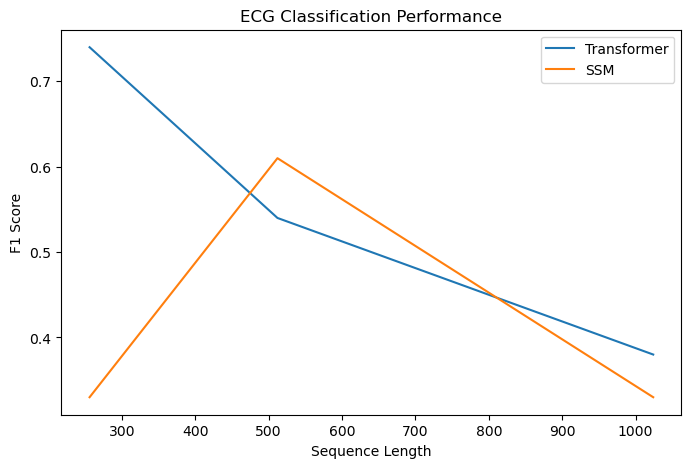

In [29]:
import matplotlib.pyplot as plt

plt.figure(
figsize=(8,5)
)

plt.plot(

df["Sequence"],

df["Transformer_F1"]

)

plt.plot(

df["Sequence"],

df["SSM_F1"]

)

plt.xlabel(
"Sequence Length"
)

plt.ylabel(
"F1 Score"
)

plt.title(
"ECG Classification Performance"
)

plt.legend([
"Transformer",
"SSM"
])

plt.show()

In [31]:
from sklearn.metrics import (
classification_report,
confusion_matrix
)

import matplotlib.pyplot as plt



def evaluate(
model,
loader
):

    model.eval()

    preds=[]

    trues=[]

    with torch.no_grad():

        for X,y in loader:

            X=X.unsqueeze(1)

            pred=model(X)

            pred=pred.argmax(
                dim=1
            )

            preds.extend(
                pred.numpy()
            )

            trues.extend(
                y.numpy()
            )

    print(
classification_report(
trues,
preds
)
)

    cm = confusion_matrix(
        trues,
        preds
    )

    plt.figure(
        figsize=(5,5)
    )

    plt.imshow(
        cm
    )

    plt.title(
        "Confusion Matrix"
    )

    plt.colorbar()

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.show()

    return trues,preds

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.50      1.00      0.67       120
           1       0.00      0.00      0.00       120

    accuracy                           0.50       240
   macro avg       0.25      0.50      0.33       240
weighted avg       0.25      0.50      0.33       240



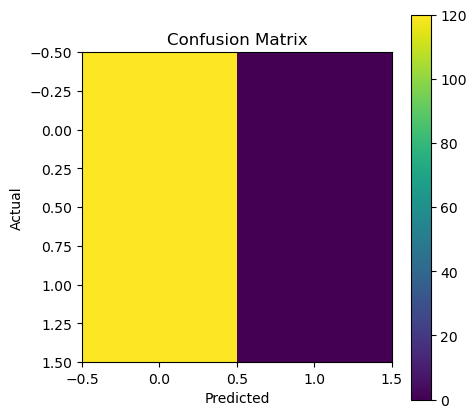

In [33]:
trues,preds = evaluate(
model,
test_loader
)

In [34]:
from sklearn.metrics import confusion_matrix

print(
confusion_matrix(
trues,
preds
)
)

[[120   0]
 [120   0]]


In [35]:
records = [
"100",
"101",
"102",
"103",
"104"
]

In [36]:
all_segments = []

all_labels = []

In [38]:
record = wfdb.rdrecord(
    f"../data/mit-bih-arrhythmia-database-1.0.0/{rec}"
)

annotation = wfdb.rdann(
    f"../data/mit-bih-arrhythmia-database-1.0.0/{rec}",
    "atr"
)

In [39]:
import wfdb

record = wfdb.rdrecord(
    "../data/mit-bih-arrhythmia-database-1.0.0/101"
)

print(record.p_signal.shape)

(650000, 2)


In [40]:
records = [
    "100",
    "101",
    "102",
    "103",
    "104",
    "105",
    "106"
]

In [41]:
import wfdb
import numpy as np

window_size = 512

all_segments = []

all_labels = []

records = [
    "100",
    "101",
    "102",
    "103",
    "104",
    "105",
    "106"
]

for rec in records:

    print("Loading", rec)

    record = wfdb.rdrecord(
        f"../data/mit-bih-arrhythmia-database-1.0.0/{rec}"
    )

    annotation = wfdb.rdann(
        f"../data/mit-bih-arrhythmia-database-1.0.0/{rec}",
        "atr"
    )

    signal = record.p_signal[:,0]

    for i in range(
        0,
        len(signal)-window_size,
        window_size
    ):

        segment = signal[
            i:i+window_size
        ]

        label = 0

        for beat,symbol in zip(
            annotation.sample,
            annotation.symbol
        ):

            if (
                beat >= i
                and
                beat < i+window_size
            ):

                if symbol != "N":

                    label = 1
                    break

        all_segments.append(
            segment
        )

        all_labels.append(
            label
        )

print(
    "Total segments:",
    len(all_segments)
)

Loading 100
Loading 101
Loading 102
Loading 103
Loading 104
Loading 105
Loading 106
Total segments: 8883


In [42]:
all_segments = np.array(
    all_segments,
    dtype=np.float32
)

all_labels = np.array(
    all_labels
)

print(all_segments.shape)
print(all_labels.shape)

(8883, 512)
(8883,)


In [43]:
print(
    np.bincount(
        all_labels
    )
)

[5747 3136]


In [44]:
all_segments = (
    all_segments
    -
    np.mean(all_segments)
) / np.std(all_segments)

print(
    np.mean(all_segments)
)

print(
    np.std(all_segments)
)

9.206747e-08
1.0


In [45]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    random_state=42
)

X_resampled,\
y_resampled = ros.fit_resample(
    all_segments,
    all_labels
)

print(
    X_resampled.shape
)

print(
    np.bincount(y_resampled)
)

(11494, 512)
[5747 5747]


In [46]:
from sklearn.model_selection import train_test_split

X_train,\
X_test,\
y_train,\
y_test = train_test_split(

    X_resampled,

    y_resampled,

    test_size=0.2,

    random_state=42,

    stratify=y_resampled
)

print(X_train.shape)
print(X_test.shape)

(9195, 512)
(2299, 512)


In [47]:
from torch.utils.data import DataLoader

train_dataset = ECGDataset(
    X_train,
    y_train
)

test_dataset = ECGDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print(
    len(train_loader),
    len(test_loader)
)

144 36


In [50]:
import torch
import torch.nn as nn


class ECGTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.input_proj = nn.Linear(
            1,
            32
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32,
            nhead=2,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1
        )

        self.fc = nn.Linear(
            32,
            2
        )

    def forward(self, x):

        # x shape:
        # [batch, 1, 512]

        x = x.transpose(
            1,
            2
        )

        # [batch, 512, 1]

        x = self.input_proj(
            x
        )

        # [batch, 512, 32]

        x = self.transformer(
            x
        )

        # Global Average Pooling

        x = x.mean(
            dim=1
        )

        # [batch, 32]

        x = self.fc(
            x
        )

        return x

In [51]:
model = ECGTransformer()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)

train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    epochs=5
)

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5


              precision    recall  f1-score   support

           0       0.80      0.92      0.86      1150
           1       0.91      0.77      0.83      1149

    accuracy                           0.84      2299
   macro avg       0.85      0.84      0.84      2299
weighted avg       0.85      0.84      0.84      2299



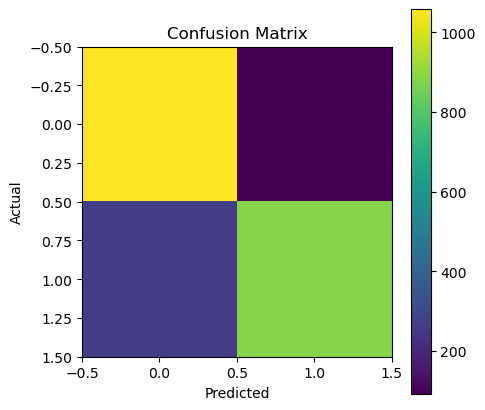

In [52]:
trues, preds = evaluate(
    model,
    test_loader
)

In [53]:
for X, y in train_loader:

    print(X.shape)

    break

torch.Size([64, 512])


In [54]:
print("train_model" in globals())

print("evaluate" in globals())

True
True


In [2]:
print("X_train" in globals())
print("train_loader" in globals())
print("train_model" in globals())
print("evaluate" in globals())

False
False
False
False
